In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

In [5]:
from neural_data.models import *
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import (
    show_single_channel_red_green_black as S,
    to_show_list as tsl,
    show_72,
    show_72_list,
    scatter_plot_1d,
    mk_rect_on_ax,
    get_receptive,
    otsu_threshold,
    explain_variance_with_pca,
)
from tqdm import tqdm
from pt_to_api.contribs.v1 import (
    show_input_patch_and_kernel_placement_for_poi_using_raw_params as SIP,
)
import seaborn as sns
import numpy as np
from sklearn.decomposition import MiniBatchDictionaryLearning, DictionaryLearning
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import (
    pairwise_distances,
    cosine_similarity,
    cosine_distances,
)
from scipy.optimize import linear_sum_assignment
import pandas as pd

from neural_data.utils import (
    get_full_conv_kernel_at_coordinate,
    get_saliency_map_ids_and_patches,
    get_full_activations_of_layer,
)
from collections import defaultdict
import itertools

# Verify diag code

In [11]:
n_comps = 4
good_tensor = torch.tensor(
    [
        [1,2,0,0,0],
        [0,0,0,0,1],
        [0,0,1,0,0],
        [0,0,0,4,0],
    ]
)
overlapped_tensor = torch.tensor(
    [
        [1,2,0,0,0],
        [0,1,1,0,1],
        [0,0,1,0,0],
        [3,0,0,4,0],
    ]
)
good_tensor.shape, overlapped_tensor.shape

(torch.Size([4, 5]), torch.Size([4, 5]))

In [ ]:
D_sq = good_tensor ** 2
D_sq

tensor([[ 1,  4,  0,  0,  0],
        [ 0,  0,  0,  0,  1],
        [ 0,  0,  1,  0,  0],
        [ 0,  0,  0, 16,  0]])

In [9]:
D_sq.T

tensor([[ 1,  0,  0,  0],
        [ 4,  0,  0,  0],
        [ 0,  0,  1,  0],
        [ 0,  0,  0, 16],
        [ 0,  1,  0,  0]])

In [13]:
B_sq = overlapped_tensor ** 2
B_sq

tensor([[ 1,  4,  0,  0,  0],
        [ 0,  1,  1,  0,  1],
        [ 0,  0,  1,  0,  0],
        [ 9,  0,  0, 16,  0]])

In [15]:
B_sq.T

tensor([[ 1,  0,  0,  9],
        [ 4,  1,  0,  0],
        [ 0,  1,  1,  0],
        [ 0,  0,  0, 16],
        [ 0,  1,  0,  0]])

In [16]:
gram = B_sq @ B_sq.T 
gram

tensor([[ 17,   4,   0,   9],
        [  4,   3,   1,   0],
        [  0,   1,   1,   0],
        [  9,   0,   0, 337]])

In [18]:
torch.diag(torch.diag(gram))

tensor([[ 17,   0,   0,   0],
        [  0,   3,   0,   0],
        [  0,   0,   1,   0],
        [  0,   0,   0, 337]])

# Model

In [18]:

KERNEL_COORDINATE = "layers.2.out_12"
INPUT_LAYER_NAME = "layers.1"
R = 2
C = 3
MODE = "dark"

100%|██████████| 5502/5502 [00:00<00:00, 1930488.59it/s]


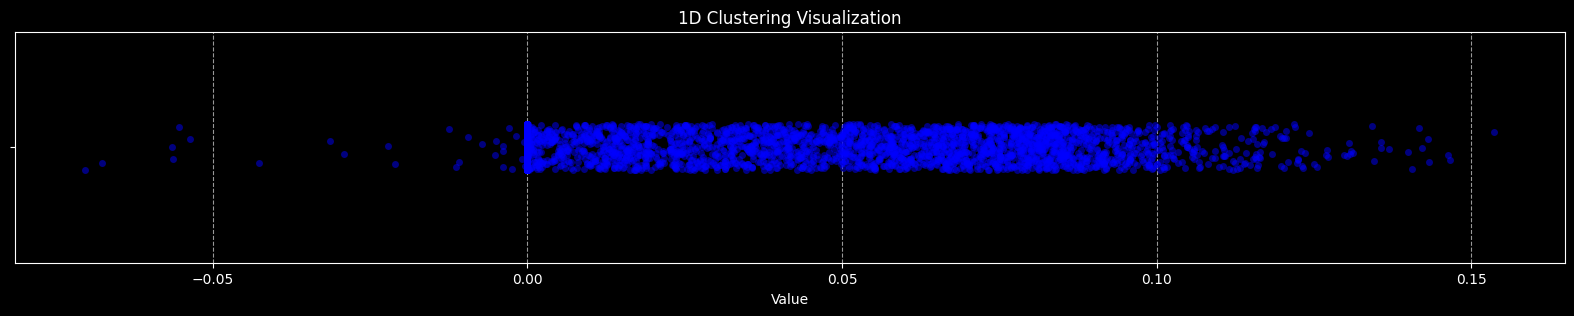

In [19]:
kernel = get_full_conv_kernel_at_coordinate(KERNEL_COORDINATE)
vals = []
for sm in tqdm(SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE)):
    vals.append(sm.data[R][C])

scatter_plot_1d(vals)

In [20]:
pos_thresh = otsu_threshold([v for v in vals if v >= 0])
neg_thresh = otsu_threshold([v for v in vals if v <= 0])

pos_thresh, neg_thresh

(np.float64(0.05252243877829671), np.float64(-0.028957475901204788))

In [11]:
# get with lower thresholds
from neural_data.utils import get_all_saliency_map_ids_and_patches

sm_ids, patches = get_saliency_map_ids_and_patches(
    (R, C), KERNEL_COORDINATE, INPUT_LAYER_NAME, pos_thresh, neg_thresh
)
pw = [p * kernel for p in patches]
lin_pw = np.array([p.reshape(-1) for p in pw])

100%|██████████| 5502/5502 [00:03<00:00, 1444.41it/s]


In [24]:
# torch.stack(lin_pw).shape
torch.tensor(lin_pw).shape

torch.Size([1449, 72])

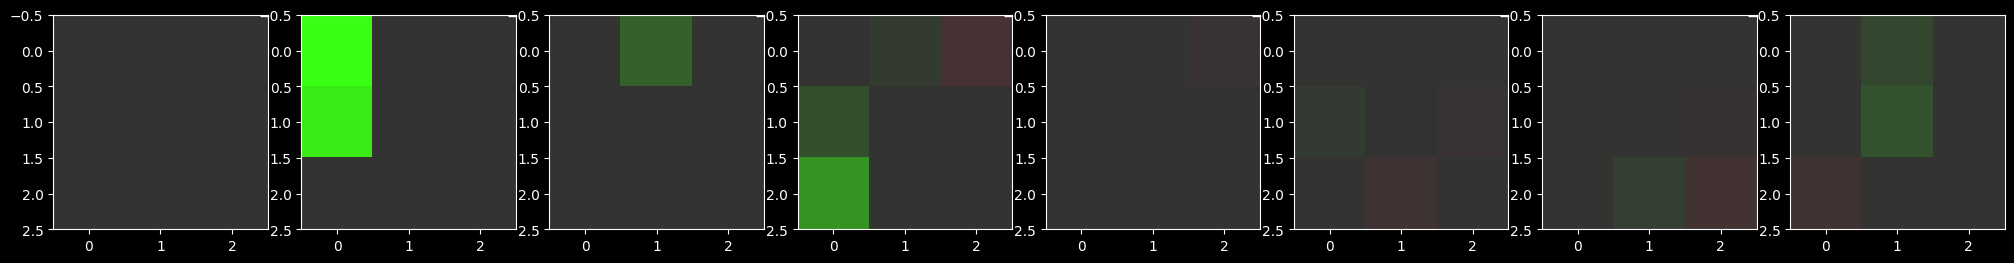

In [21]:
show_72(lin_pw[0])

In [26]:
torch.tensor(lin_pw).dtype

torch.float64

In [77]:
def show_for_ip(idx, codes, atoms, lin_pw, recons):
    print("X vs recons")
    show_72_list([lin_pw[idx], recons[idx]])
    print("### components used ###")
    used = [atoms[i] for i, c in enumerate(codes[idx]) if c != 0]
    show_72_list(used)

In [133]:
import torch
import torch.nn as nn


class DisjointDictionaryLearning(nn.Module):
    def __init__(self, input_dim: int, n_atoms: int, n_samples: int):
        super().__init__()
        self.input_dim = input_dim
        self.n_atoms = n_atoms
        self.n_samples = n_samples

        # D: (n_atoms, input_dim)
        self.D = nn.Parameter(torch.randn(n_atoms, input_dim))

        # Z: (n_atoms, n_samples), rows normalized to unit norm
        Z_init = torch.randn(n_atoms, n_samples)
        # Z_init = Z_init / Z_init.norm(dim=1, keepdim=True).clamp(min=1e-8)
        self.Z = nn.Parameter(Z_init)
        self.normalize_Z()


    def forward(self):
        # (n_samples, input_dim)
        return self.Z.relu().T @ self.D

    def reconstruction_loss(self, X):
        x_hat = self.forward()
        return torch.nn.functional.mse_loss(x_hat, X, reduction='sum')

    def disjointness_penalty(self):
        D_sq = self.D ** 2  # (n_atoms, input_dim)
        gram = D_sq @ D_sq.T  # (n_atoms, n_atoms)
        off_diag = gram - torch.diag(torch.diag(gram))
        return off_diag.sum()

    def normalize_Z(self):
        with torch.no_grad():
            norms = self.Z.relu().norm(dim=1, keepdim=True).clamp(min=1e-8)
            self.Z.data = self.Z.data / norms

    def atom_collapse_penalty(self):
        # penalizes atoms for having small norms
        # D: (n_atoms, input_dim)
        return self.D.abs().sum()


def fit(
    # model: DisjointDictionaryLearning,
    n_atoms: int,
    X: torch.Tensor,
    lam: float = 1.0,
    collapse_alpha: float = 1.0,
    n_iter: int = 1000,
    lr: float = 1e-3,
    normalize_every: int = 10,
    verbose: bool = True,
    verbose_every: int = 100,
):
    # X: n_samples, input_dim
    # 
    model = DisjointDictionaryLearning(X.shape[1], n_atoms, X.shape[0])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for i in range(n_iter):
        optimizer.zero_grad()

        recon = model.reconstruction_loss(X)
        penalty = lam * model.disjointness_penalty()
        collapse_penalty = collapse_alpha * model.atom_collapse_penalty()
        loss = recon + penalty + collapse_penalty

        loss.backward()
        optimizer.step()

        if (i + 1) % normalize_every == 0:
            model.normalize_Z()

        if verbose and (i + 1) % verbose_every == 0:
            print(
                f"iter {i+1:4d} | loss {loss.item():.4f} "
                f"| recon {recon.item():.4f} | penalty {penalty.item():.4f} | collapse-penalty {collapse_penalty.item():4f}"
            )
    return model

## lin-pw raw

In [ ]:
model = fit(10, torch.tensor(lin_pw).float(), n_iter=20_000, lr=0.005)

iter  100 | loss 6354.9897 | recon 4426.4409 | penalty 1928.5488
iter  200 | loss 4683.7471 | recon 3806.2476 | penalty 877.4994
iter  300 | loss 4036.0840 | recon 3495.1785 | penalty 540.9056
iter  400 | loss 3756.8135 | recon 3357.9636 | penalty 398.8499
iter  500 | loss 3622.5928 | recon 3292.2881 | penalty 330.3048
iter  600 | loss 3553.9106 | recon 3259.7432 | penalty 294.1676
iter  700 | loss 3513.3481 | recon 3237.4214 | penalty 275.9268
iter  800 | loss 3489.9302 | recon 3225.8059 | penalty 264.1243
iter  900 | loss 3460.5505 | recon 3208.1252 | penalty 252.4254
iter 1000 | loss 3430.4890 | recon 3195.2161 | penalty 235.2729
iter 1100 | loss 3396.0845 | recon 3179.1660 | penalty 216.9185
iter 1200 | loss 3367.6453 | recon 3163.8823 | penalty 203.7629
iter 1300 | loss 3346.9746 | recon 3157.0703 | penalty 189.9044
iter 1400 | loss 3328.6267 | recon 3157.4189 | penalty 171.2078
iter 1500 | loss 3304.4058 | recon 3155.0127 | penalty 149.3930
iter 1600 | loss 3269.3081 | recon 3139

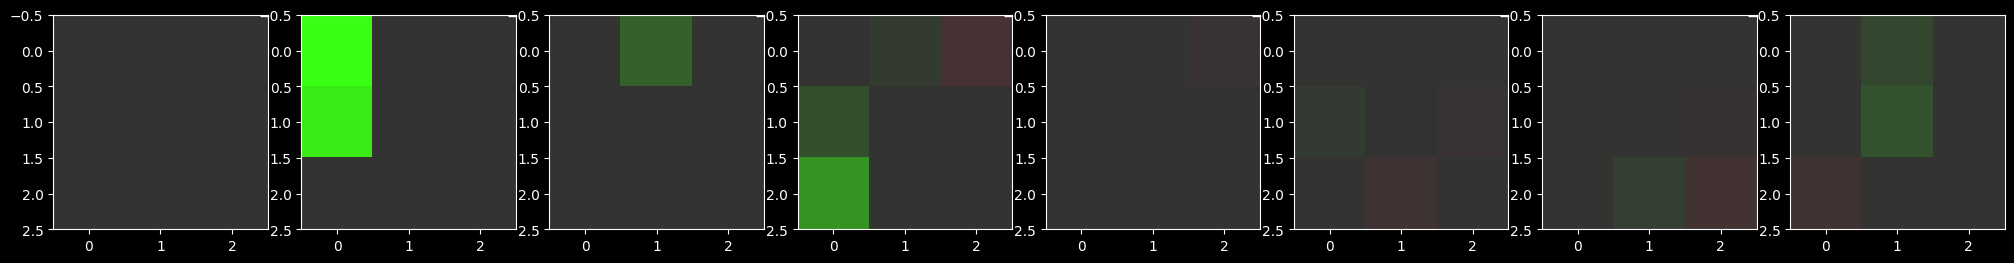

In [39]:
show_72(lin_pw[0])

In [ ]:
model.eval()

codes = model.Z.relu().T.clone().detach().cpu().numpy()
atoms = model.D.clone().detach().cpu().numpy()
recons = codes @ atoms

X vs recons


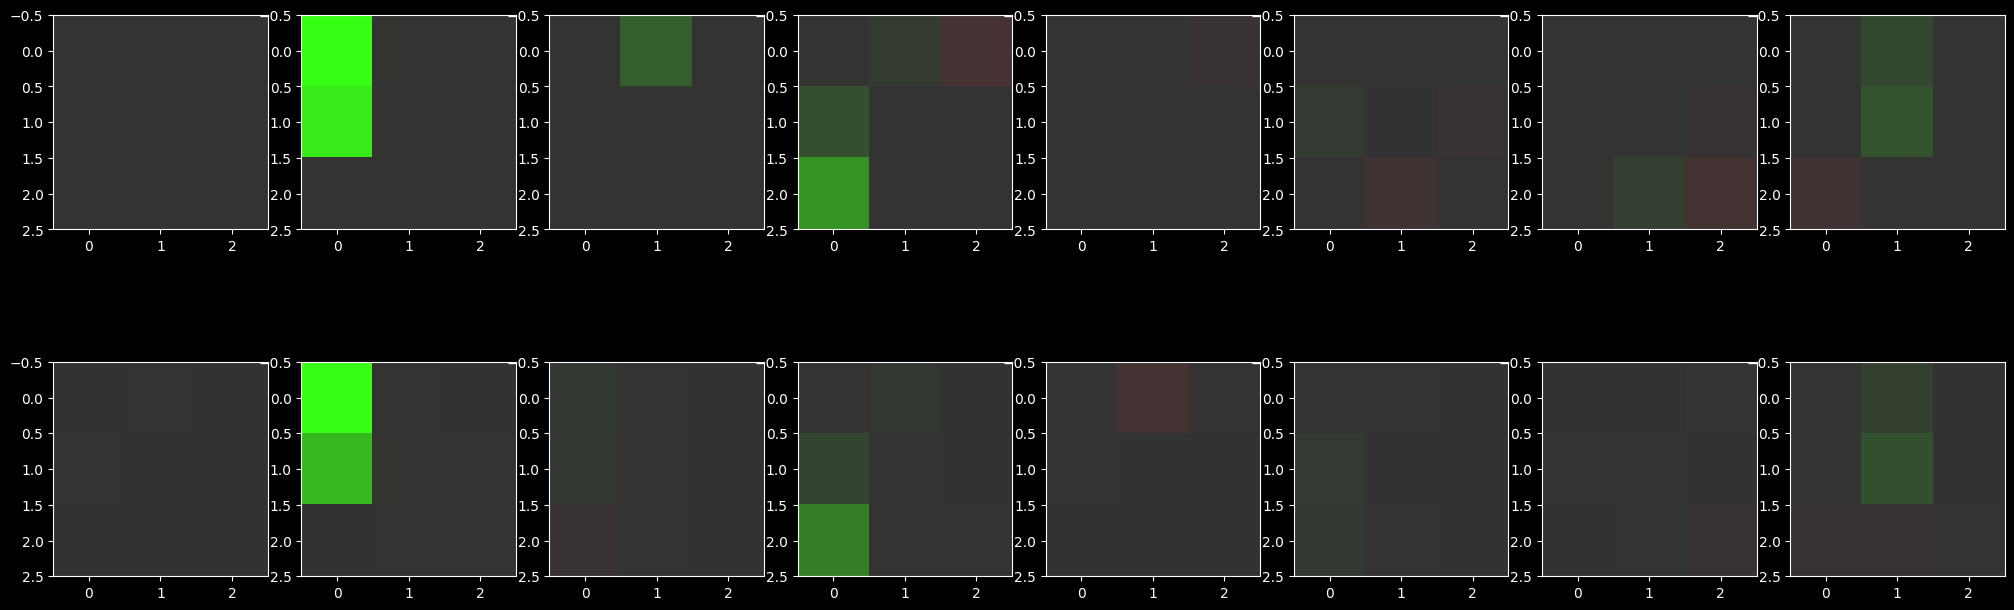

### components used ###


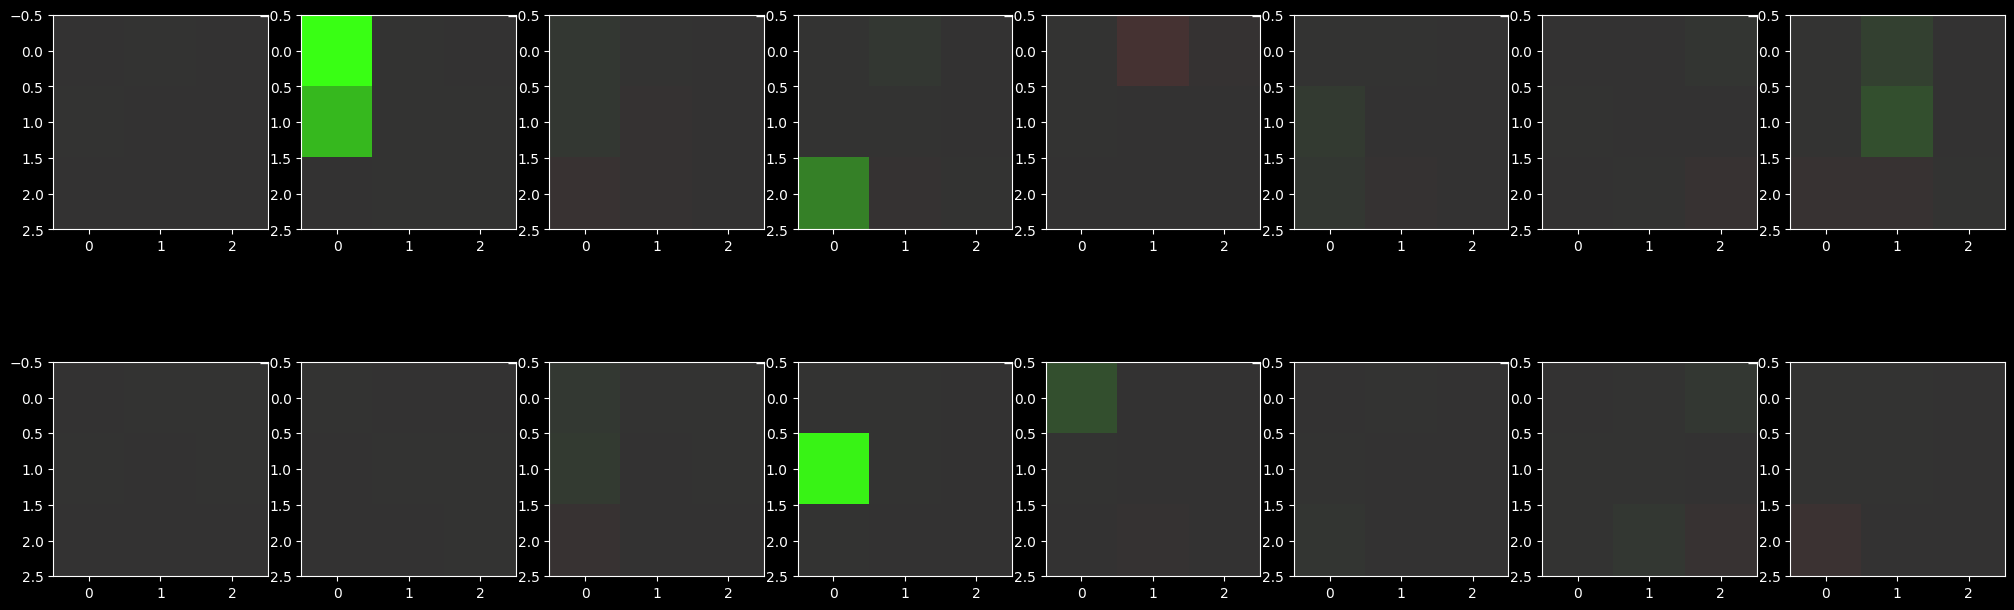

In [73]:
show_for_ip(0, codes, atoms, lin_pw, recons)

X vs recons


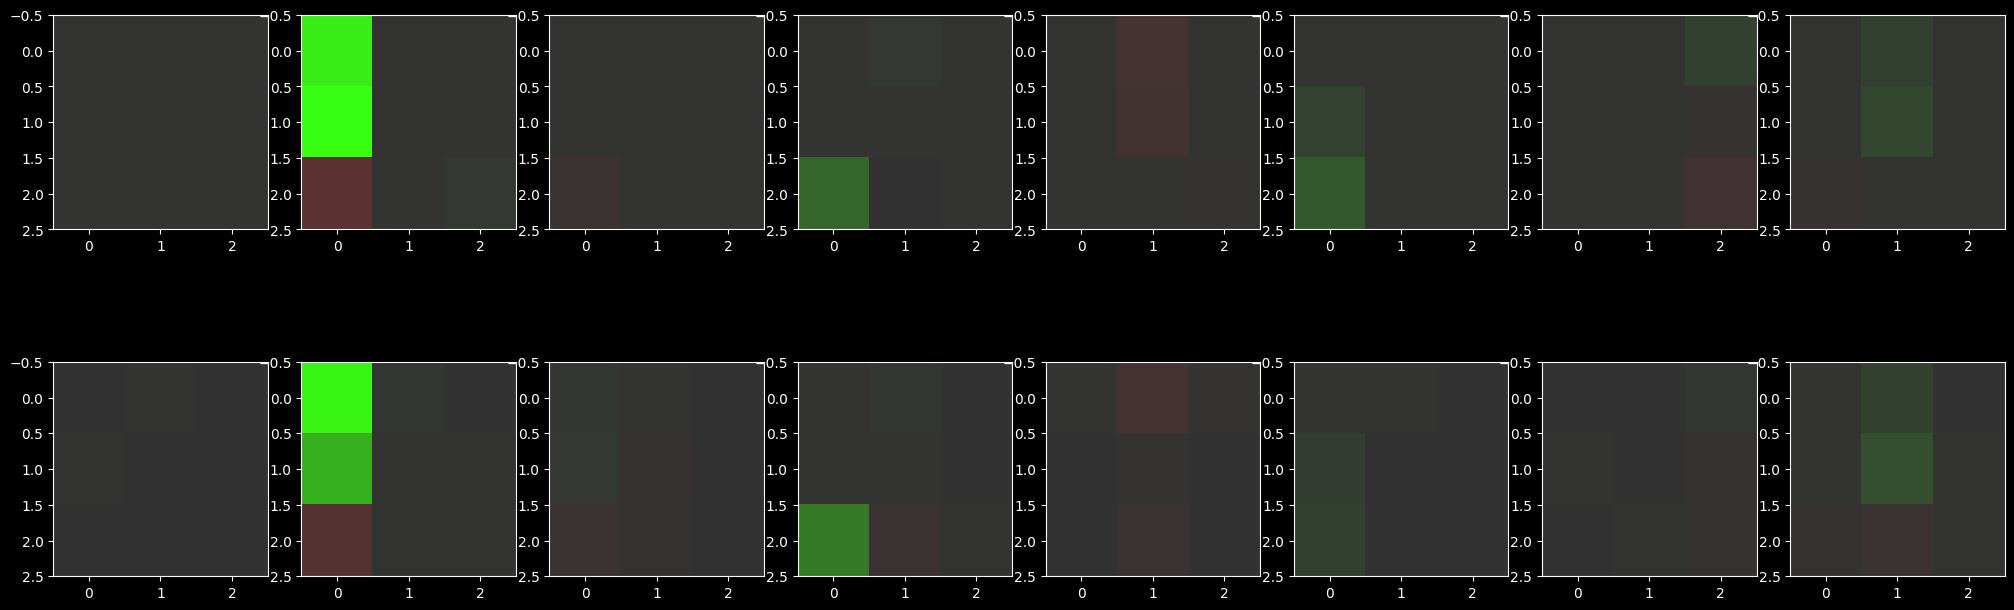

### components used ###


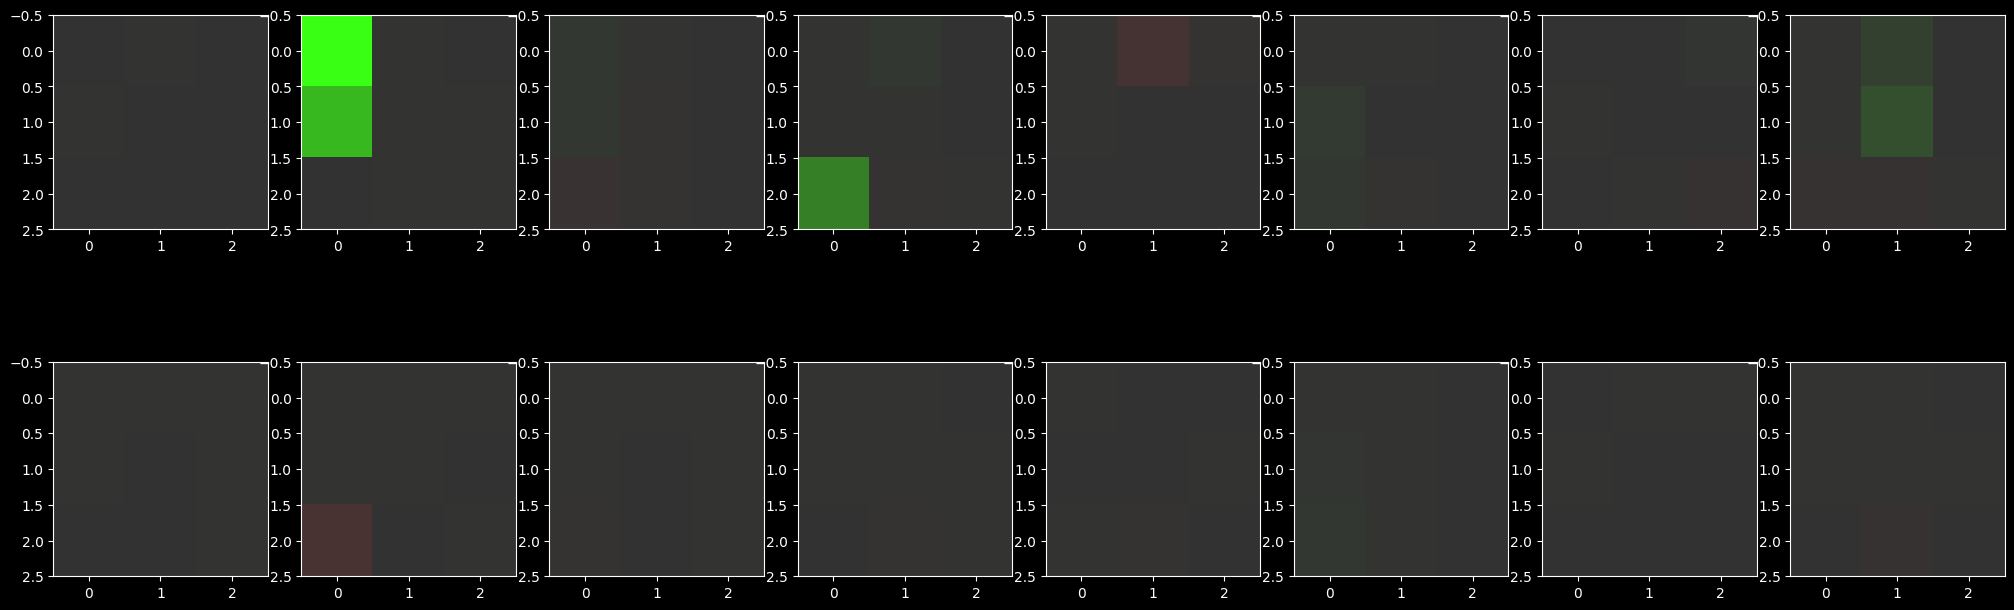

In [74]:
show_for_ip(1, codes, atoms, lin_pw, recons)

X vs recons


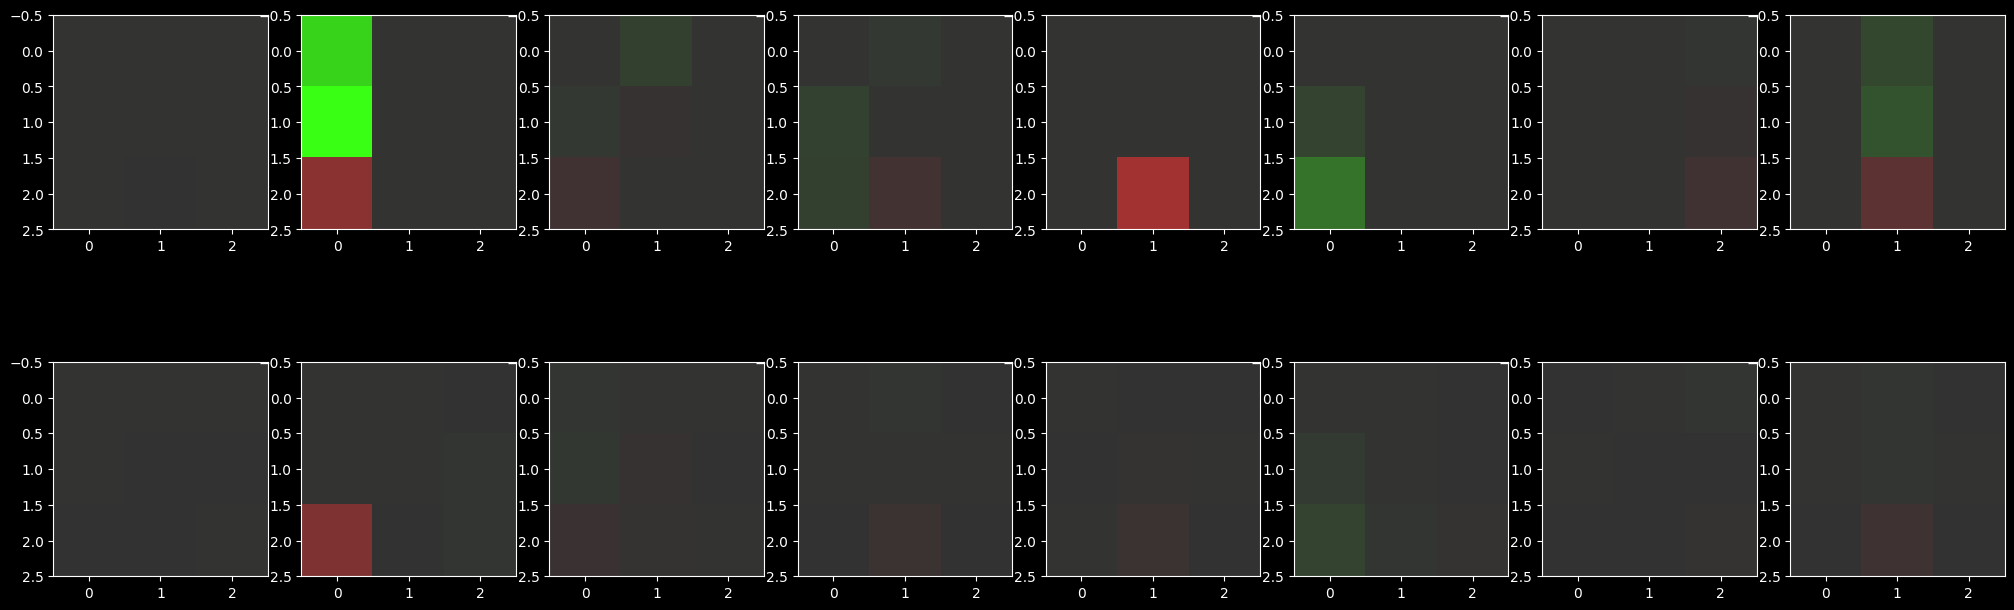

### components used ###


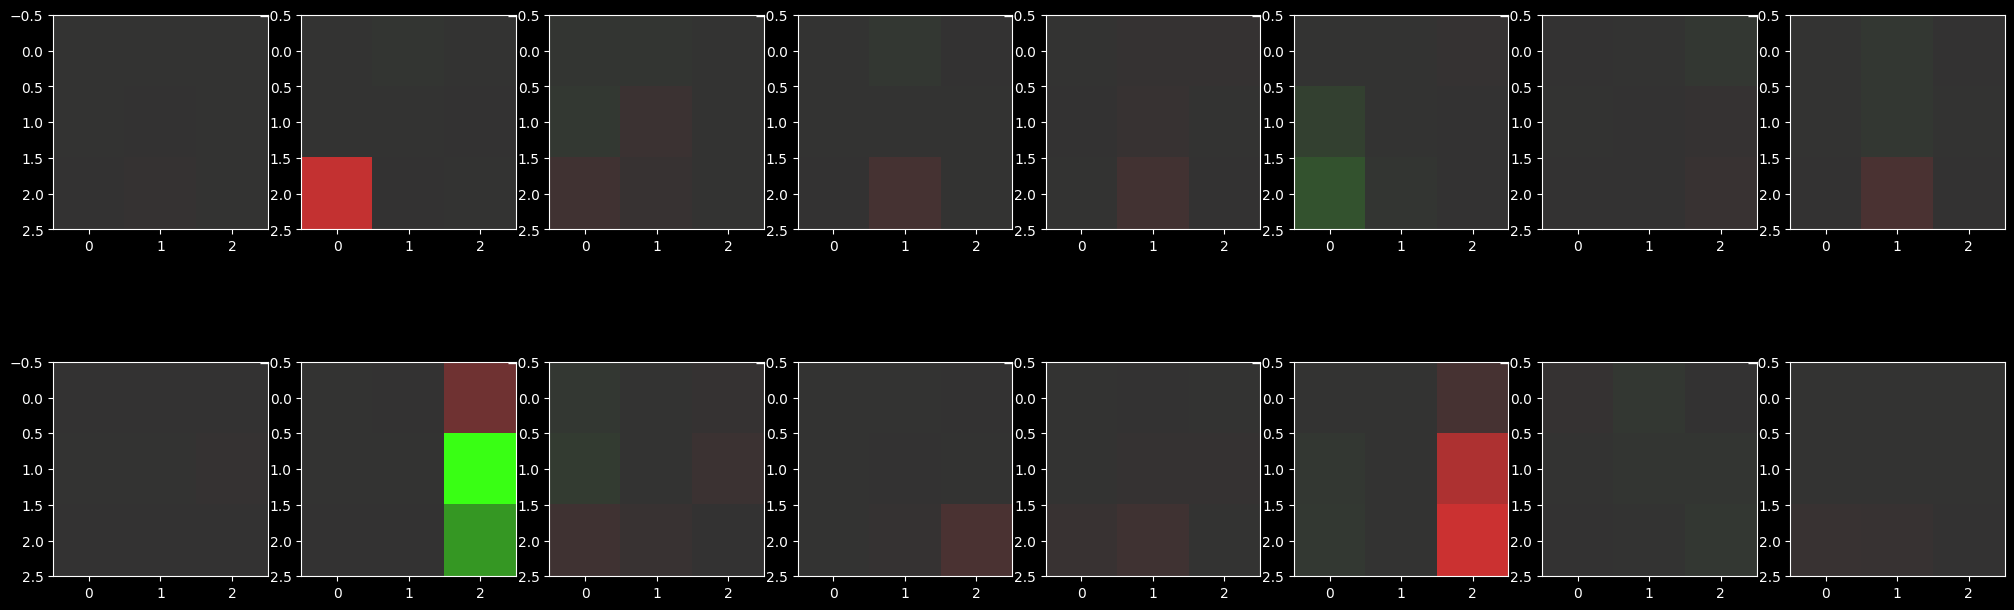

In [75]:
show_for_ip(2, codes, atoms, lin_pw, recons)

X vs recons


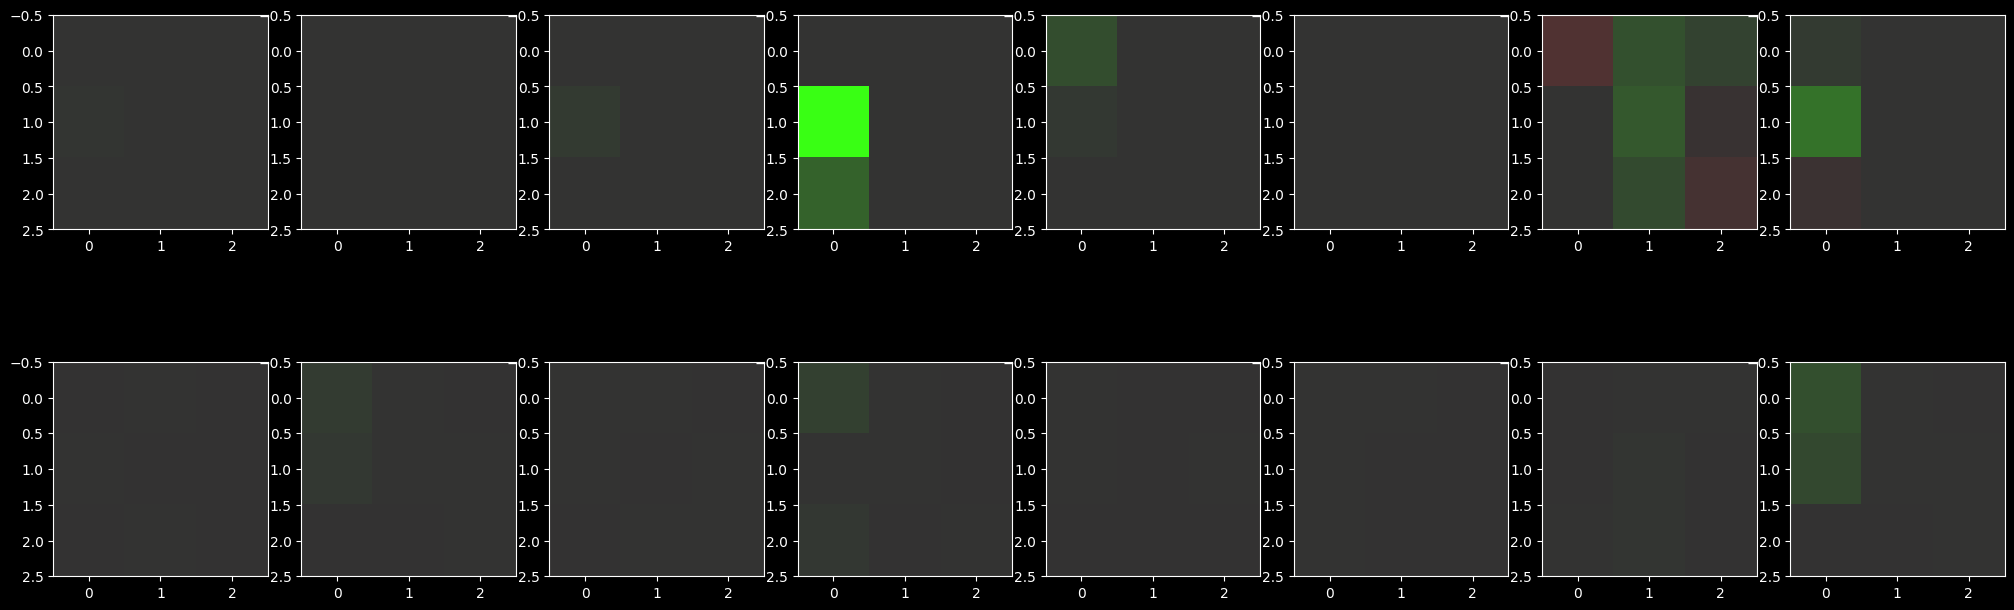

### components used ###


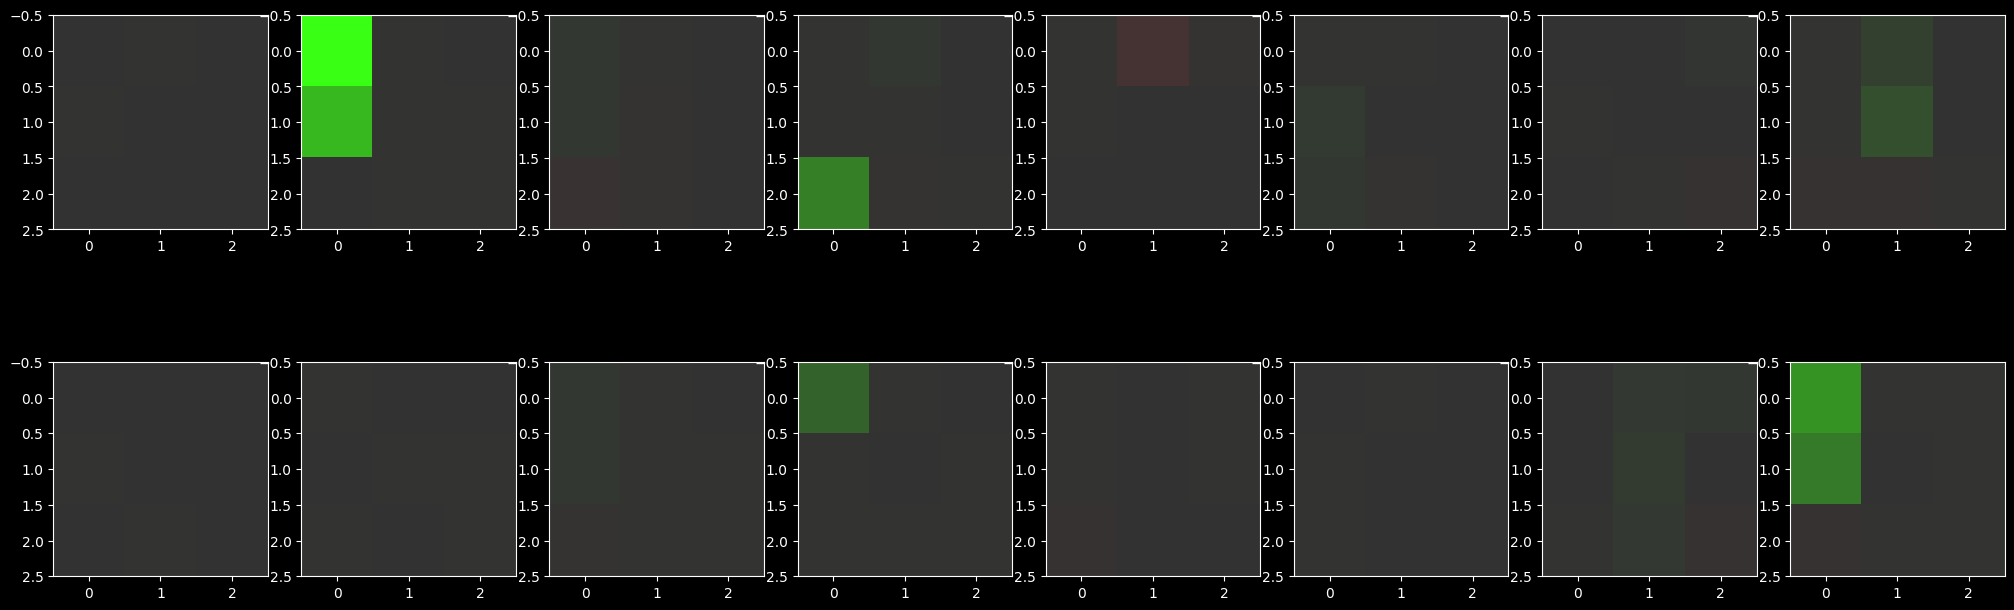

In [76]:
show_for_ip(3, codes, atoms, lin_pw, recons)

The sparsity punishes stuff which is "low". Makes loss harder to interpret. Lets make the input sparse then

## Sparse inputs

In [233]:
def make_sparse_at_percentile_signs_separately(vectors, pos_percent=50, neg_percent=50):
    # zeros out the bottom `percentile`% of magnitudes per vector
    pos_thres = np.percentile(lin_pw[lin_pw > 0], pos_percent, axis=1, keepdims=True)
    neg_thres = np.percentile(lin_pw[lin_pw < 0], neg_percent, axis=1, keepdims=True)
    sparse = vectors.copy()
    sparse[sparse < pos_thres and sparse > 0] = 0
    sparse[sparse > neg_thres  and sparse < 0] = 0
    # sparse[np.abs(sparse) < thresh] = 0
    return sparse

def make_sparse(vectors, pos_percentile=50, neg_percentile=50):
    # vectors: (n_samples, k)
    sparse = vectors.copy()

    pos_mask = vectors > 0
    neg_mask = vectors < 0

    # threshold positive values
    pos_vals = np.where(pos_mask, vectors, np.nan)
    pos_thresh = np.nanpercentile(pos_vals, pos_percentile, axis=1, keepdims=True)
    sparse[pos_mask & (vectors < pos_thresh)] = 0

    # threshold negative values
    neg_vals = np.where(neg_mask, np.abs(vectors), np.nan)
    neg_thresh = np.nanpercentile(neg_vals, neg_percentile, axis=1, keepdims=True)
    sparse[neg_mask & (np.abs(vectors) < neg_thresh)] = 0

    return sparse

In [232]:
lin_pw[lin_pw > 0] 

array([1.13848495, 1.03002108, 0.25139799, ..., 0.0535688 , 0.1506611 ,
       0.3086509 ], shape=(21832,))

In [207]:
s0 = lin_pw[0].reshape(8,3,3)
s0[1, 0, 0], s0[2, 0, 1], s0[3, 1, 0]

(np.float64(1.1384849476353338),
 np.float64(0.2513979899480834),
 np.float64(0.15625141196480286))

In [238]:
sparse_pw = make_sparse(lin_pw, 50, 50)

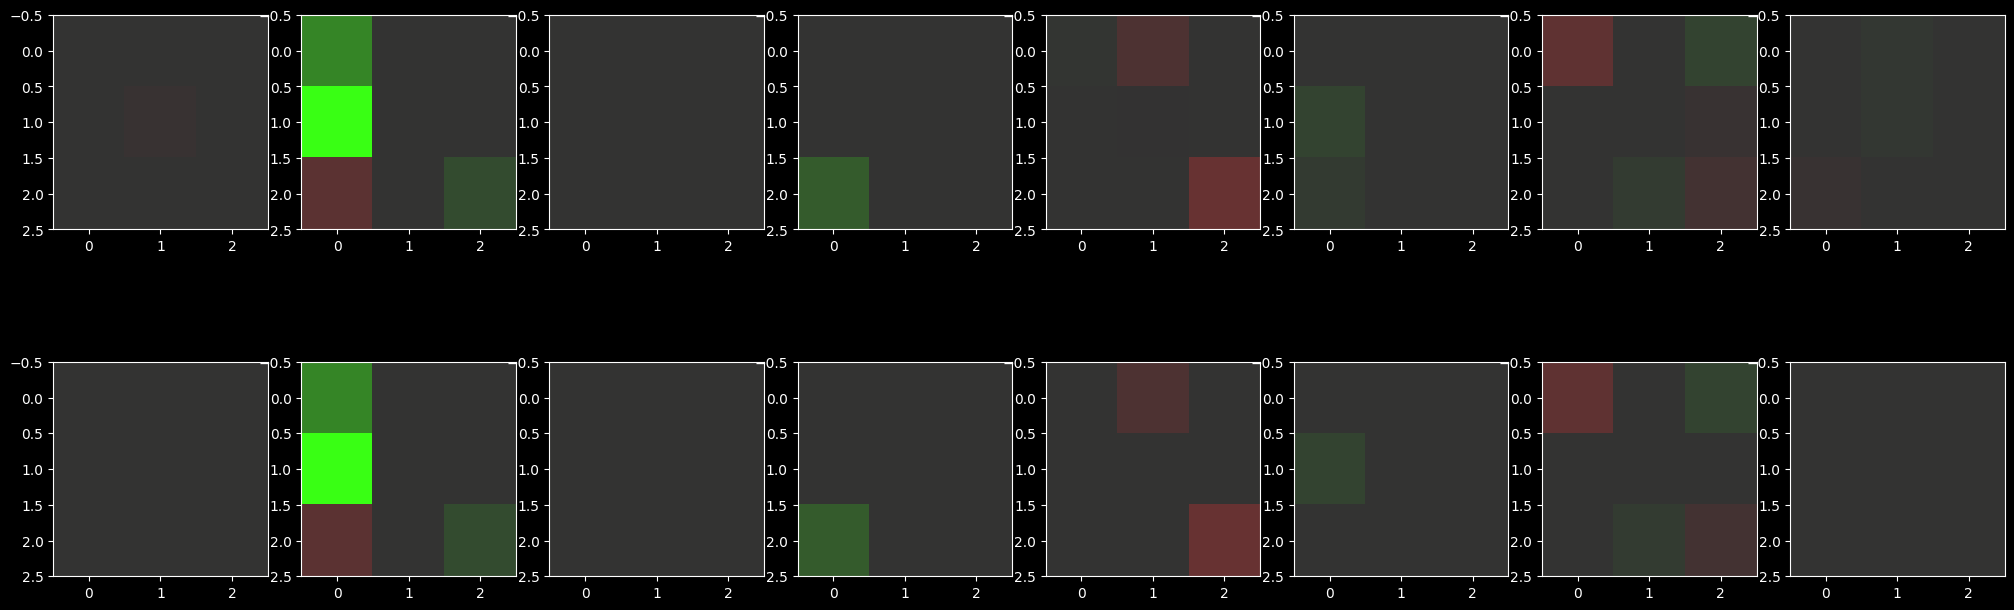

In [244]:
i = 7
show_72_list([lin_pw[i], sparse_pw[i]])

In [245]:
# sparse_pw = make_sparse_at_percentile(lin_pw, 50)
model = fit(10, torch.tensor(sparse_pw).float(), lam=10, collapse_alpha=0, n_iter=20_000, lr=0.005)

iter  100 | loss 25889.0879 | recon 5127.2300 | penalty 20761.8574 | collapse-penalty 0.000000
iter  200 | loss 13268.6855 | recon 5016.1377 | penalty 8252.5479 | collapse-penalty 0.000000
iter  300 | loss 8957.6191 | recon 4931.3618 | penalty 4026.2568 | collapse-penalty 0.000000
iter  400 | loss 7077.7607 | recon 4846.8672 | penalty 2230.8933 | collapse-penalty 0.000000
iter  500 | loss 6106.7109 | recon 4755.4990 | penalty 1351.2122 | collapse-penalty 0.000000
iter  600 | loss 5521.8447 | recon 4655.2378 | penalty 866.6072 | collapse-penalty 0.000000
iter  700 | loss 5140.1899 | recon 4559.5459 | penalty 580.6439 | collapse-penalty 0.000000
iter  800 | loss 4889.2344 | recon 4480.1084 | penalty 409.1259 | collapse-penalty 0.000000
iter  900 | loss 4714.9780 | recon 4413.1577 | penalty 301.8203 | collapse-penalty 0.000000
iter 1000 | loss 4590.0859 | recon 4357.4814 | penalty 232.6047 | collapse-penalty 0.000000
iter 1100 | loss 4495.6953 | recon 4308.5498 | penalty 187.1456 | collap

In [246]:
model.eval()

codes = model.Z.relu().T.clone().detach().cpu().numpy()
atoms = model.D.clone().detach().cpu().numpy()
recons = codes @ atoms

X vs recons


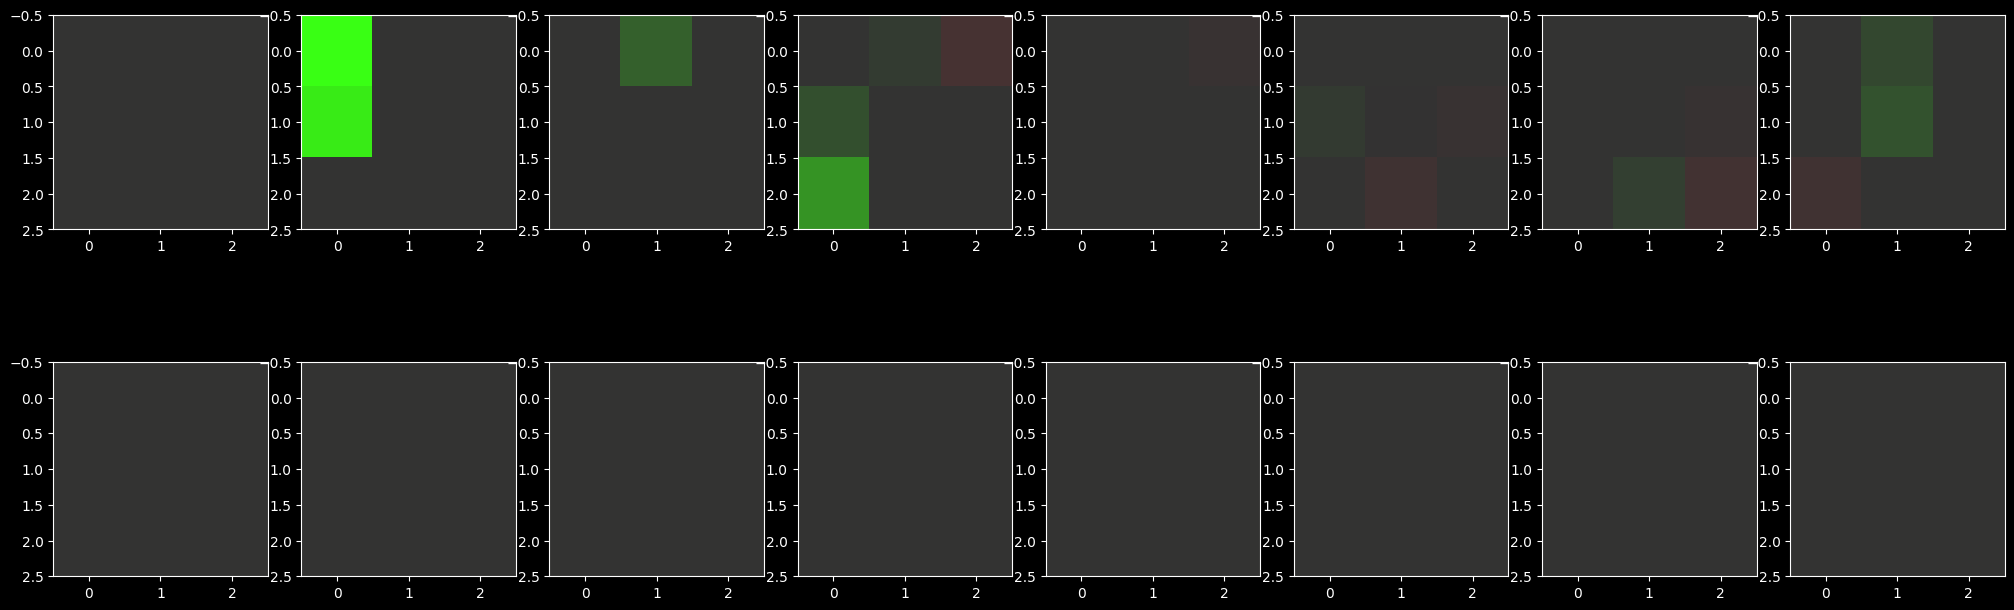

### components used ###


In [248]:
show_for_ip(0, codes, atoms, lin_pw, recons)

X vs recons


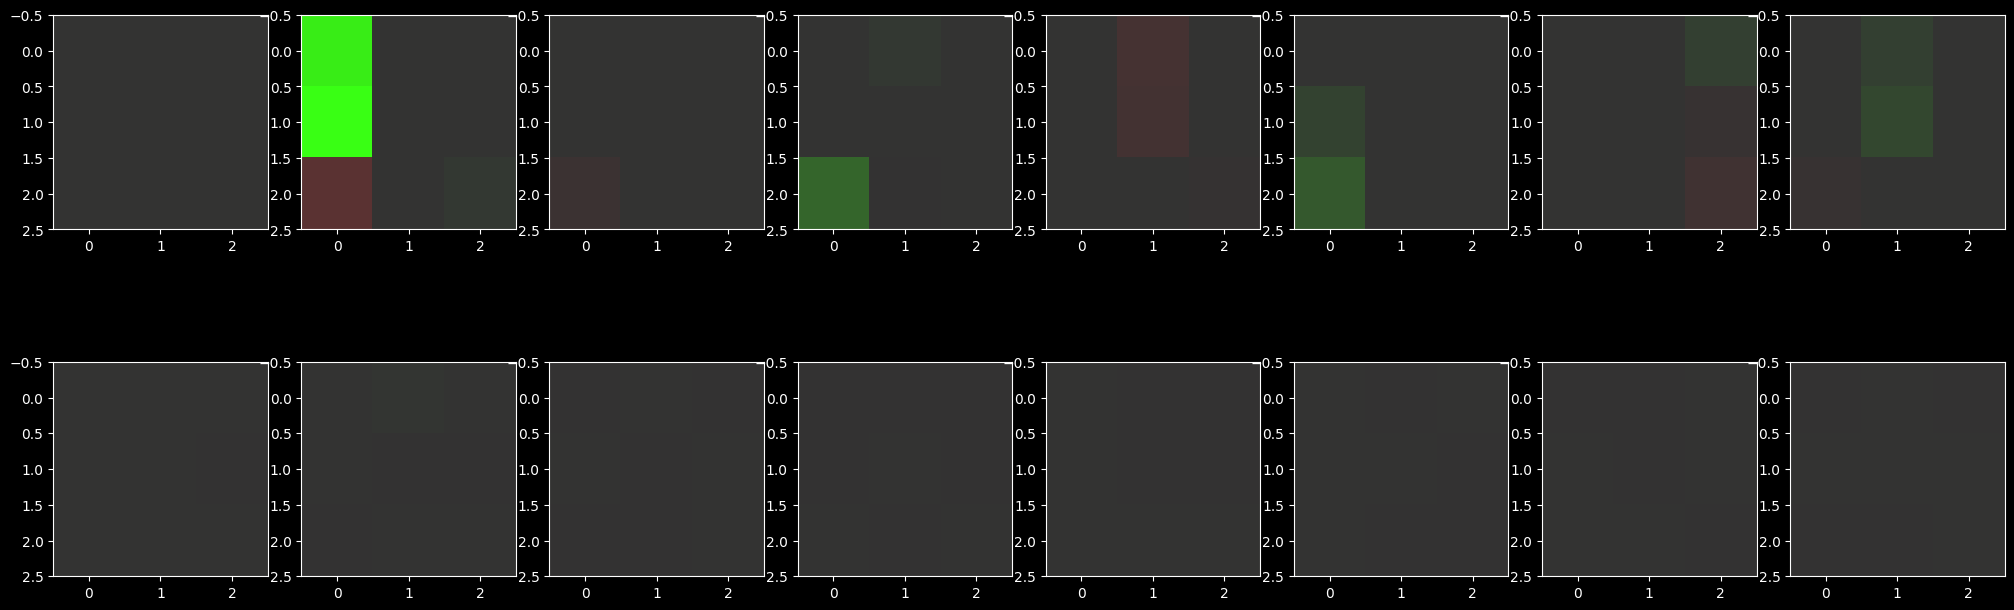

### components used ###


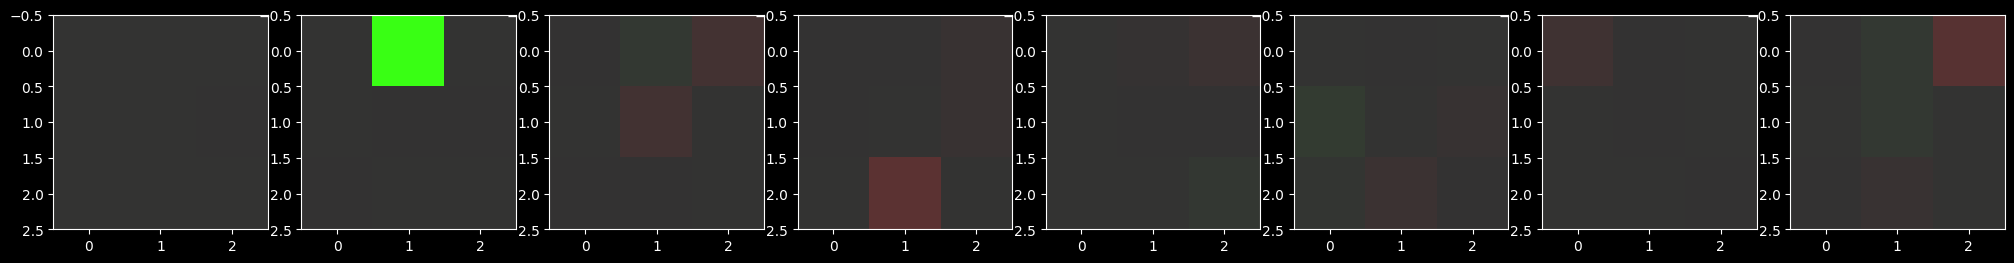

In [249]:
show_for_ip(1, codes, atoms, lin_pw, recons)

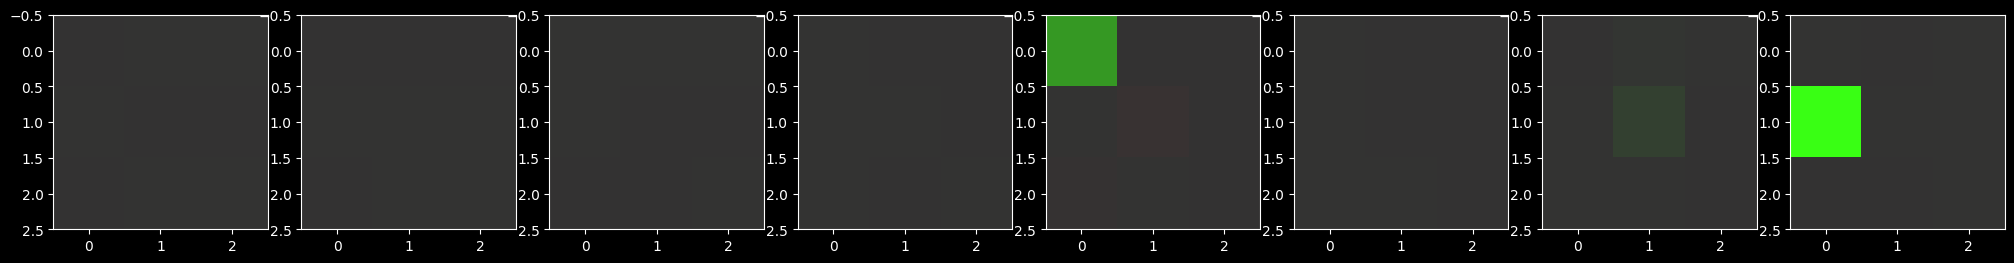

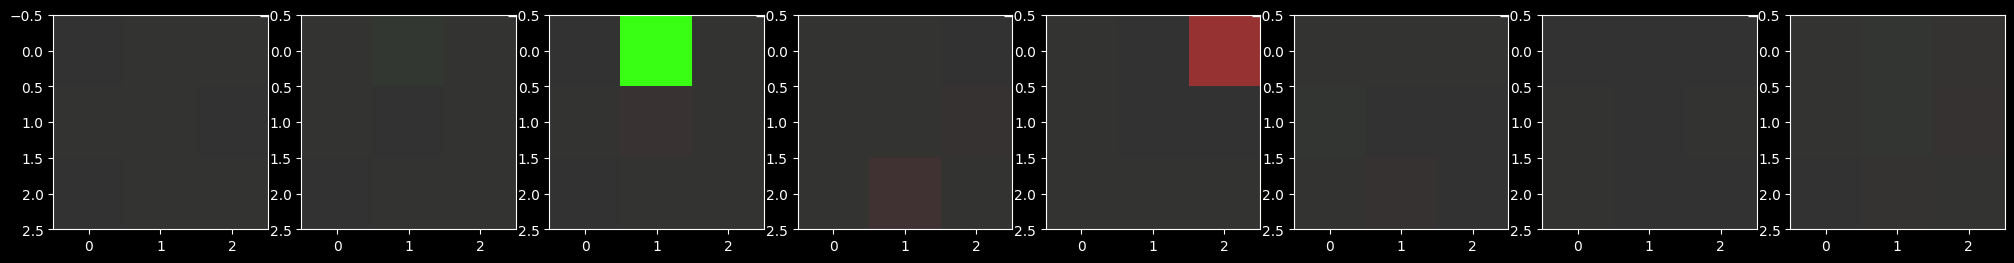

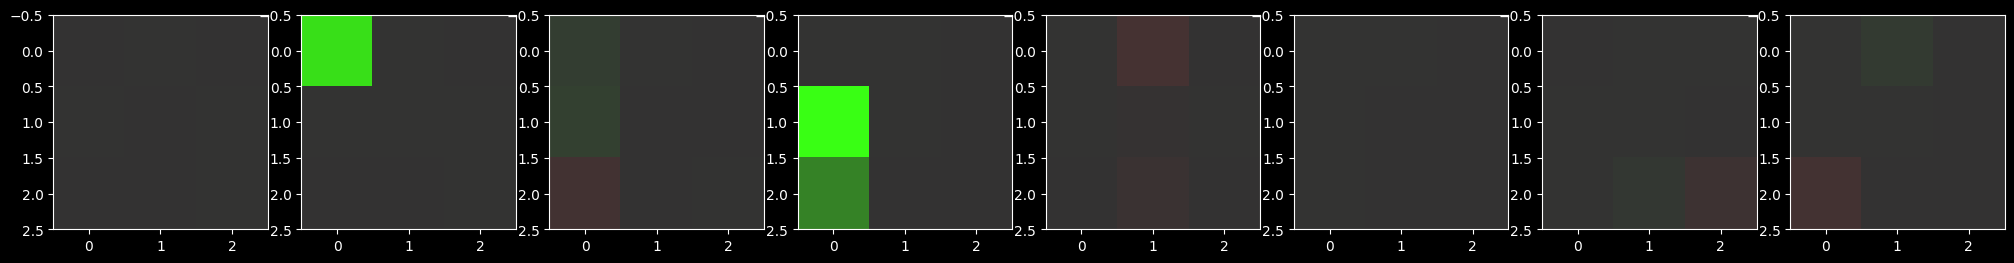

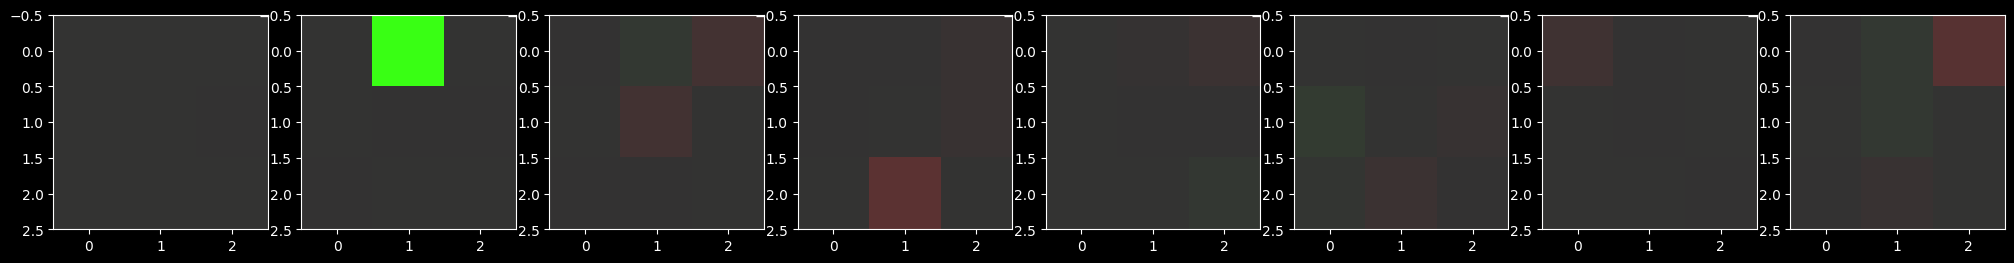

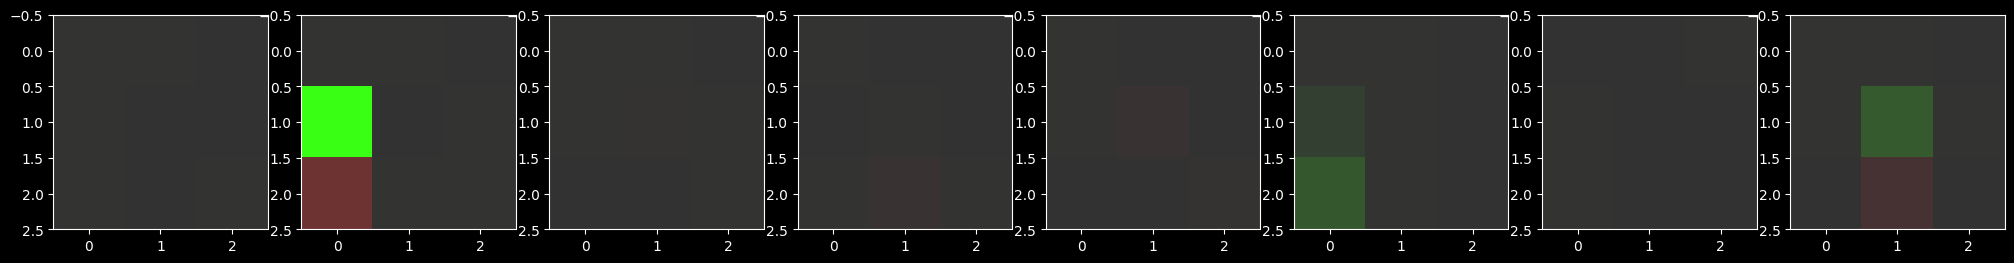

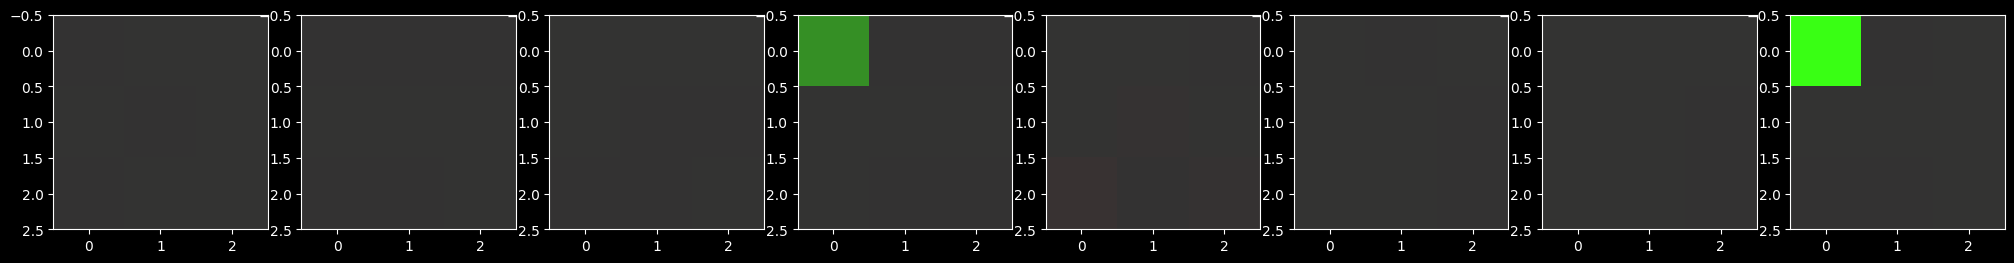

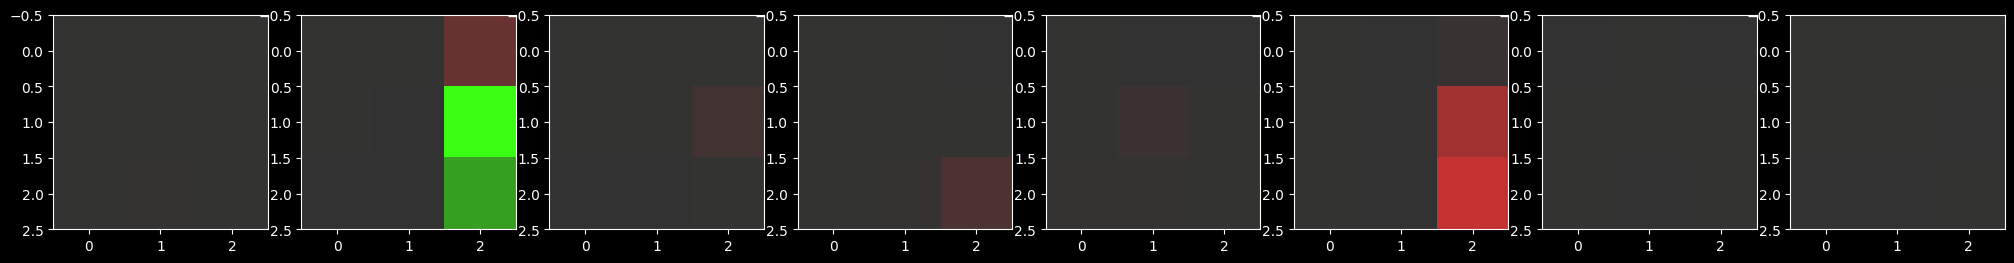

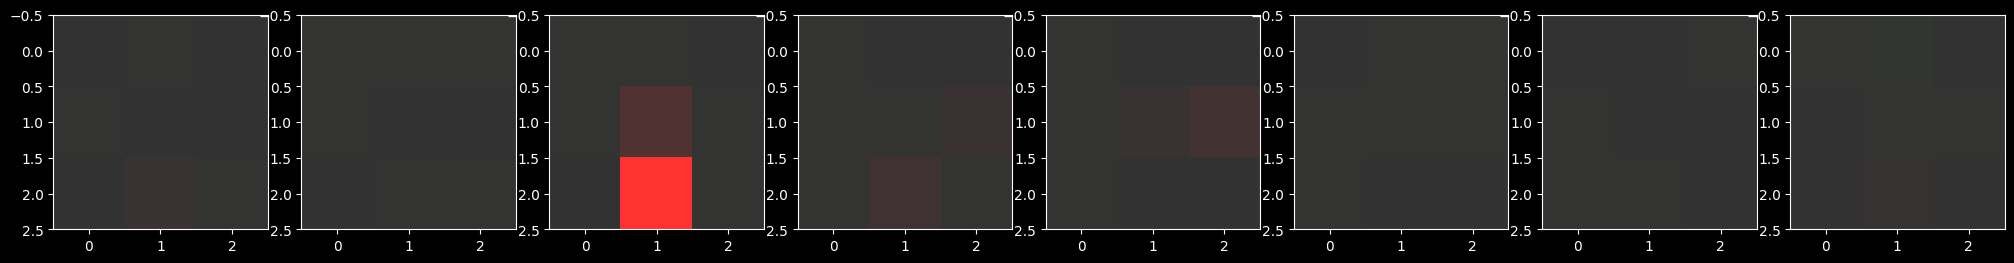

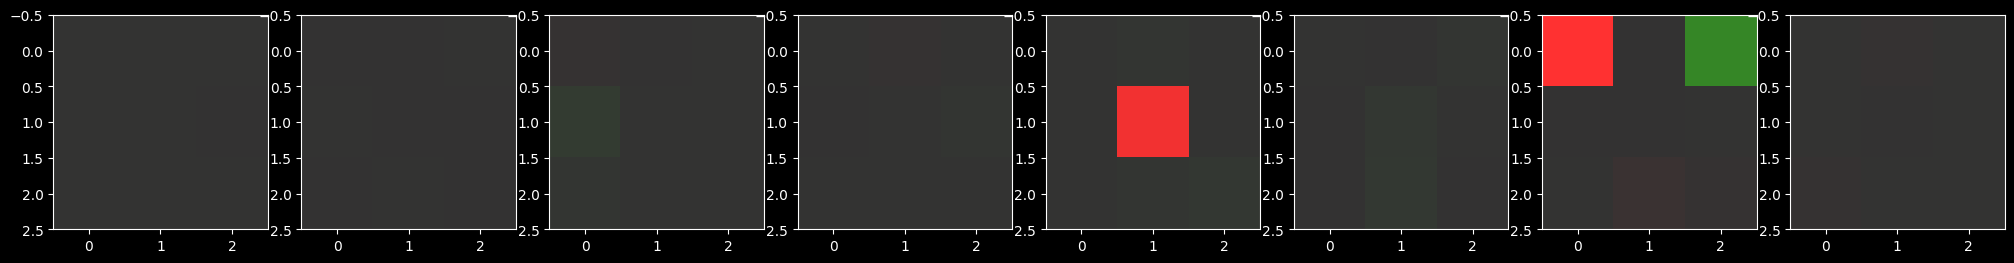

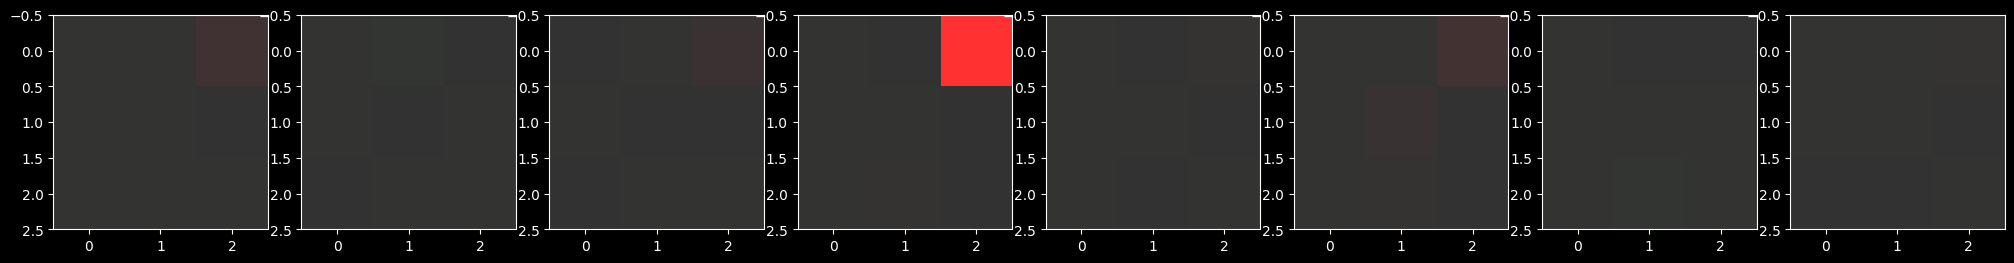

In [250]:
for a in atoms:
    show_72(a)
# atoms.shape